# 06.1 — Active Hallucination Detection (AHD) — OpenAI

Notebook ini mengimplementasi **Konfigurasi D** dari proposal: RAG Hybrid + Active Hallucination Detection.

## Pipeline

```
Question
  ↓
Hybrid Retrieval (BM25 + Dense via RRF) → top-5
  ↓
LLM Generate initial answer (yes/no/maybe + explanation)
  ↓
═══════════════ AHD Phase A: Detection ═══════════════
  ↓
Extract concepts (Adaptive 2-6, LLM-instructed)
  ↓
For each concept:
    ├── Generate Y/N validation question
    ├── Reuse top-5 context as evidence
    └── LLM answer Y/N validation question
  ↓
═══════════════ AHD Phase B: Mitigation ══════════════
  ↓
Aggregate failed concepts (count k of N)
  ↓
If k/N > 0.70  → REFUSAL: label="maybe" + guard rail explanation
Else if k >= 1 → MITIGATION: regenerate dengan warning eksplisit
Else           → PASS-THROUGH: keep initial answer
  ↓
Final Answer
```

## Konfigurasi (sesuai keputusan)

| Parameter | Nilai |
|---|---|
| Concept extraction | Adaptive (LLM decide 2-6) |
| Evidence retrieval | Reuse top-5 dari generation awal |
| Mitigation strategy | Full regeneration dengan warning |
| Mitigation trigger | >=1 concept failed |
| Refusal threshold | >70% concepts failed → label="maybe" |
| Guard rail | Output disclaimer kalau evidence kurang |
| Validation answer | 2-class (yes/no) |
| Sampel | 100 (subset) |

## Sumber riset

Varshney et al. 2023, "A Stitch in Time Saves Nine: Detecting and Mitigating Hallucinations of LLMs by Validating Low-Confidence Generation" (arXiv:2307.03987).
Adaptasi untuk closed-source LLM (gpt-4.1-mini): skip uncertainty step, validate semua concept.


## Cell 1 — Imports & Konfigurasi

In [1]:
import os, sys, json, pickle, time, re, warnings
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from pathlib import Path
from datetime import datetime

from openai import OpenAI
from rank_bm25 import BM25Okapi
import chromadb

warnings.filterwarnings('ignore')

# ============================================================
# KONFIGURASI
# ============================================================
OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', 'YOUR_OPENAI_KEY_HERE')

LLM_MODEL   = 'gpt-4.1-mini'
EMBED_MODEL = 'text-embedding-3-small'

# Hybrid retrieval (sama dengan notebook 02.1)
TOP_K_BM25      = 50
TOP_K_DENSE     = 50
TOP_K_RETRIEVAL = 5

# AHD-specific config
CONCEPT_MIN          = 2     # min konsep adaptive
CONCEPT_MAX          = 6     # max konsep adaptive
MITIGATION_TRIGGER   = 1     # trigger kalau >=1 concept failed
REFUSAL_RATIO        = 0.70  # refusal kalau >70% failed

# Sample size
MAX_SAMPLES = 100

TEMPERATURE = 0.0
SEED        = 42

NOTEBOOK_DIR    = Path('.')
BM25_INDEX_PATH = NOTEBOOK_DIR / 'pubmedqa_bm25.pkl'
CHROMA_DB_PATH  = NOTEBOOK_DIR / 'pubmedqa_chroma'
RESULTS_DIR     = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

CONFIG_NAME        = 'ahd_openai'
PHASE1_PATH        = RESULTS_DIR / f'{CONFIG_NAME}_phase1_answers.json'
PHASE2_CUSTOM_PATH = RESULTS_DIR / f'{CONFIG_NAME}_phase2_custom.json'

print('Konfigurasi:')
print(f'  LLM             : {LLM_MODEL}')
print(f'  Embedder        : {EMBED_MODEL}')
print(f'  Hybrid          : BM25 top-{TOP_K_BM25} + Dense top-{TOP_K_DENSE} -> RRF -> top-{TOP_K_RETRIEVAL}')
print(f'  Concept range   : {CONCEPT_MIN}-{CONCEPT_MAX} (adaptive)')
print(f'  Mitigation trig : >={MITIGATION_TRIGGER} concept failed')
print(f'  Refusal thresh  : >{REFUSAL_RATIO*100:.0f}% concepts failed -> label=maybe')
print(f'  Sampel          : {MAX_SAMPLES}')
print()
if 'YOUR_API_KEY' in OPENAI_API_KEY:
    print('  OPENAI_API_KEY belum diset!')
else:
    print(f'  OPENAI_API_KEY  : {OPENAI_API_KEY[:8]}...{OPENAI_API_KEY[-4:]}')

Konfigurasi:
  LLM             : gpt-4.1-mini
  Embedder        : text-embedding-3-small
  Hybrid          : BM25 top-50 + Dense top-50 -> RRF -> top-5
  Concept range   : 2-6 (adaptive)
  Mitigation trig : >=1 concept failed
  Refusal thresh  : >70% concepts failed -> label=maybe
  Sampel          : 100

  OPENAI_API_KEY  : sk-proj-...REDACTED


## Cell 2 — Load BM25, ChromaDB, dan PubMedQA test set

In [2]:
@dataclass
class Document:
    text         : str
    pubid        : str
    question     : str
    section_label: str
    answer       : str
    decision     : str

def tokenize_bm25(text: str) -> List[str]:
    return re.sub(r'[^a-zA-Z0-9\s]', ' ', text.lower()).split()

# Load BM25
print('Loading BM25 index...')
with open(BM25_INDEX_PATH, 'rb') as f:
    bm25_data = pickle.load(f)
bm25_index = bm25_data['bm25']
documents  = bm25_data['documents']
print(f'  BM25: {len(documents)} dokumen')

# Load Chroma
print('Loading ChromaDB collection...')
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DB_PATH))
chroma_collection = chroma_client.get_collection(name='pubmedqa_docs')
print(f'  Chroma: {chroma_collection.count()} dokumen')

# Load PubMedQA test data
print('Loading PubMedQA test set...')
import csv
PUBMEDQA_CSV = Path('../data/pubmedqa_pqa_labeled.csv')
test_samples = []
with open(PUBMEDQA_CSV, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_samples.append({
            'idx'           : len(test_samples),
            'pubid'         : row['pubid'],
            'question'      : row['question'],
            'final_decision': row['final_decision'],
            'long_answer'   : row['long_answer'],
        })
        if len(test_samples) >= MAX_SAMPLES:
            break
print(f'  Loaded {len(test_samples)} test samples')

Loading BM25 index...
  BM25: 1706 dokumen
Loading ChromaDB collection...
  Chroma: 1706 dokumen
Loading PubMedQA test set...
  Loaded 100 test samples


## Cell 3 — OpenAI Client & Hybrid Retrieval Helpers

In [3]:
openai_client = OpenAI(api_key=OPENAI_API_KEY)

def openai_generate(prompt: str, max_tokens: int = 300, temperature: float = TEMPERATURE) -> str:
    """Wrapper OpenAI chat completion dengan retry."""
    for attempt in range(5):
        try:
            r = openai_client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=temperature, max_tokens=max_tokens, seed=SEED,
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            if attempt == 4: raise
            time.sleep((attempt + 1) * 5)
    raise RuntimeError('llm gagal')

def openai_embed(texts: List[str]) -> List[List[float]]:
    for attempt in range(5):
        try:
            r = openai_client.embeddings.create(model=EMBED_MODEL, input=texts)
            return [d.embedding for d in r.data]
        except Exception as e:
            if attempt == 4: raise
            time.sleep((attempt + 1) * 5)
    raise RuntimeError('embed gagal')

# ============================================================
# Hybrid retrieval (reuse pattern dari 02.1)
# ============================================================
def retrieve_dense(query: str, k: int) -> List[Tuple[int, float]]:
    qvec = openai_embed([query])[0]
    r = chroma_collection.query(query_embeddings=[qvec], n_results=k, include=['distances'])
    doc_ids   = [int(i) for i in r['ids'][0]]
    distances = r['distances'][0]
    return [(d, 1.0 - dist) for d, dist in zip(doc_ids, distances)]

def retrieve_bm25(query: str, k: int) -> List[Tuple[int, float]]:
    tokens = tokenize_bm25(query)
    scores = bm25_index.get_scores(tokens)
    top    = np.argsort(scores)[::-1][:k]
    return [(int(i), float(scores[i])) for i in top]

def reciprocal_rank_fusion(rank_lists: List[List[int]], k: int = 60) -> List[Tuple[int, float]]:
    s = {}
    for rl in rank_lists:
        for rank, did in enumerate(rl):
            s[did] = s.get(did, 0.0) + 1.0 / (k + rank + 1)
    return sorted(s.items(), key=lambda x: -x[1])

def hybrid_retrieve(query: str, top_k: int = TOP_K_RETRIEVAL) -> List[Dict]:
    """Return top-k docs as list of dict {doc_id, text, section, bm25, dense, rrf}."""
    bm25_pairs  = retrieve_bm25(query, k=TOP_K_BM25)
    dense_pairs = retrieve_dense(query, k=TOP_K_DENSE)
    bm25_scores  = dict(bm25_pairs)
    dense_scores = dict(dense_pairs)
    fused = reciprocal_rank_fusion([
        [d for d, _ in bm25_pairs],
        [d for d, _ in dense_pairs],
    ])
    out = []
    for doc_id, rrf_score in fused[:top_k]:
        d = documents[doc_id]
        out.append({
            'doc_id' : doc_id,
            'text'   : d.text,
            'section': d.section_label,
            'bm25'   : bm25_scores.get(doc_id, 0.0),
            'dense'  : dense_scores.get(doc_id, 0.0),
            'rrf'    : rrf_score,
        })
    return out

# Smoke test
test_q = 'Does aspirin reduce myocardial infarction risk?'
test_r = hybrid_retrieve(test_q, top_k=3)
print(f'Smoke test query: {test_q}')
for i, r in enumerate(test_r, 1):
    print(f'  [{i}] doc_id={r["doc_id"]} rrf={r["rrf"]:.4f} | {r["section"]} | {r["text"][:70]}...')

Smoke test query: Does aspirin reduce myocardial infarction risk?
  [1] doc_id=1418 rrf=0.0323 | DESIGN | Within a prospective, population-based cohort study individuals withou...
  [2] doc_id=1419 rrf=0.0320 | METHODS | Of the 9681 women and 8888 men who attended risk assessment from 1967-...
  [3] doc_id=430 rrf=0.0301 | OBJECTIVE | Myocardial damage that is associated with percutaneous coronary interv...


## Cell 4 — Initial Answer Generation (Standard Hybrid)

In [4]:
GENERATION_PROMPT = (
    'You are a medical research assistant. '
    'Answer a biomedical yes/no/maybe question based solely on the provided scientific abstracts.\n\n'
    'Context from medical literature:\n{context}\n\n'
    'Question: {question}\n\n'
    'Instructions:\n'
    '- Carefully read the context and assess whether it supports or refutes the question.\n'
    '- Provide a brief explanation (2-3 sentences) using ONLY the information above.\n'
    '- End your response with EXACTLY ONE of these words on its own line: yes, no, or maybe.\n'
    '  - yes   : the evidence supports the hypothesis, even if not perfectly conclusive\n'
    '  - no    : the evidence refutes or does not support the hypothesis\n'
    '  - maybe : ONLY if the evidence is directly contradictory, or if the context contains no relevant information at all\n'
    '- IMPORTANT: If the evidence leans in one direction, even partially, choose yes or no.\n\n'
    'Answer:'
)

def generate_initial_answer(question: str, contexts: List[Dict]) -> str:
    """Generate initial RAG answer with hybrid context."""
    ctx_text = '\n\n'.join(
        f'[{i+1}] ({c["section"]}): {c["text"]}'
        for i, c in enumerate(contexts)
    )
    return openai_generate(
        GENERATION_PROMPT.format(context=ctx_text, question=question),
        max_tokens=300,
    )

def extract_label(answer: str) -> str:
    """Extract yes/no/maybe label from answer text."""
    lines = [l.strip().lower() for l in answer.split('\n') if l.strip()]
    for line in reversed(lines[-3:]):
        word = re.sub(r'[^a-z]', '', line)
        if word in ('yes', 'no', 'maybe'):
            return word
    for label in ('yes', 'no', 'maybe'):
        if re.search(r'\b' + label + r'\b', answer.lower()):
            return label
    return 'maybe'

# Smoke test
test_ctx = hybrid_retrieve(test_q, top_k=TOP_K_RETRIEVAL)
test_ans = generate_initial_answer(test_q, test_ctx)
print('Initial answer (smoke test):')
print('-' * 60)
print(test_ans)
print('-' * 60)
print(f'Extracted label: {extract_label(test_ans)}')

Initial answer (smoke test):
------------------------------------------------------------
The provided abstracts discuss myocardial infarction risk factors, outcomes related to interventions like PCI, and the effects of statins on stroke risk, but none mention aspirin or its impact on myocardial infarction risk. Therefore, there is no direct evidence in the given context to support or refute the effect of aspirin on myocardial infarction risk.

maybe
------------------------------------------------------------
Extracted label: maybe


## Cell 5 — AHD Phase A: Concept Extraction (Adaptive)

Extract 2-6 konsep faktual penting dari initial answer. LLM decide jumlahnya berdasarkan kompleksitas jawaban.

In [5]:
CONCEPT_EXTRACTION_PROMPT = (
    'Identify the {min_n} to {max_n} most important factual concepts from this medical answer '
    'that should be verified for correctness. Skip generic words and trivial qualifiers. '
    'Be selective — only extract concepts that, if wrong, would make the answer factually incorrect.\n\n'
    'A concept can be: a specific claim (e.g., "aspirin reduces MI risk"), an entity '
    '(e.g., "elderly patients"), a numeric value (e.g., "20-25% reduction"), or a relationship '
    '(e.g., "benefit greatest with prior CV events").\n\n'
    'Return as a numbered list, one concept per line. No explanations.\n\n'
    'Answer to analyze:\n{answer}\n\n'
    'Important concepts:'
)

def extract_concepts(answer: str, min_n: int = CONCEPT_MIN, max_n: int = CONCEPT_MAX) -> List[str]:
    """Extract adaptive 2-6 concepts from answer text."""
    prompt = CONCEPT_EXTRACTION_PROMPT.format(min_n=min_n, max_n=max_n, answer=answer)
    raw = openai_generate(prompt, max_tokens=200, temperature=0.0)

    # Parse numbered list
    concepts = []
    for line in raw.split('\n'):
        line = line.strip()
        if not line:
            continue
        # Strip leading "1.", "1)", "-", "*" markers
        cleaned = re.sub(r'^[\d]+[.)\]]\s*', '', line)
        cleaned = re.sub(r'^[-*•]\s*', '', cleaned).strip()
        if len(cleaned) >= 5 and len(cleaned) <= 200:
            concepts.append(cleaned)

    # Clamp ke range
    concepts = concepts[:max_n]
    if len(concepts) < min_n:
        # Fallback: split answer ke kalimat-kalimat
        sents = re.split(r'(?<=[.!?])\s+', answer.strip())
        for s in sents:
            s = s.strip()
            if len(s) >= 15 and s not in concepts and not s.lower() in ('yes', 'no', 'maybe'):
                concepts.append(s)
                if len(concepts) >= min_n:
                    break
    return concepts[:max_n]

# Smoke test
test_concepts = extract_concepts(test_ans)
print(f'Extracted {len(test_concepts)} concepts:')
for i, c in enumerate(test_concepts, 1):
    print(f'  [{i}] {c}')

Extracted 5 concepts:
  [1] Myocardial infarction risk factors discussed in the abstracts
  [2] Outcomes related to interventions like PCI mentioned in the abstracts
  [3] Effects of statins on stroke risk discussed in the abstracts
  [4] Absence of mention of aspirin or its impact on myocardial infarction risk in the abstracts
  [5] No direct evidence in the given context to support or refute aspirin's effect on myocardial infarction risk


## Cell 6 — AHD Phase A: Validation Question Generation + Answering

Untuk tiap concept:
1. Generate Y/N validation question
2. Reuse top-5 context sebagai evidence
3. LLM answer "yes" atau "no"

Concept yang dapat "no" → flag sebagai unsupported (potential hallucination).

In [6]:
VALIDATION_QUESTION_PROMPT = (
    'Given the original medical question and a factual concept that needs to be verified, '
    'generate a single Yes/No question that tests whether this concept is factually supported.\n\n'
    'Original question: {question}\n'
    'Concept to verify: {concept}\n\n'
    'Output ONLY the Yes/No validation question. No explanations.\n\n'
    'Validation question:'
)

VALIDATION_ANSWER_PROMPT = (
    'Based ONLY on the medical evidence provided below, answer the validation question with '
    'EXACTLY ONE WORD: "yes" if the evidence supports the claim, "no" if the evidence does not support '
    'or contradicts the claim. If evidence is insufficient or unclear, default to "no".\n\n'
    'Evidence:\n{evidence}\n\n'
    'Validation question: {validation_q}\n\n'
    'Answer (yes/no):'
)

def generate_validation_question(question: str, concept: str) -> str:
    raw = openai_generate(
        VALIDATION_QUESTION_PROMPT.format(question=question, concept=concept),
        max_tokens=80, temperature=0.0,
    )
    # Take first non-empty line
    for line in raw.split('\n'):
        line = line.strip()
        if line and '?' in line:
            return line
    return raw.strip()

def answer_validation_question(validation_q: str, evidence: str) -> str:
    """Returns 'yes' or 'no'. Defaults to 'no' if unparseable."""
    raw = openai_generate(
        VALIDATION_ANSWER_PROMPT.format(evidence=evidence, validation_q=validation_q),
        max_tokens=10, temperature=0.0,
    )
    text = raw.strip().lower()
    if text.startswith('yes'):
        return 'yes'
    return 'no'

def validate_concepts(question: str, concepts: List[str], contexts: List[Dict]) -> List[Dict]:
    """
    Validate each concept against the evidence (reused top-5 context).
    Returns list of dict per concept: {concept, validation_q, validation_a, supported}
    """
    evidence = '\n\n'.join(
        f'[{i+1}] ({c["section"]}): {c["text"]}'
        for i, c in enumerate(contexts)
    )
    results = []
    for c in concepts:
        vq = generate_validation_question(question, c)
        va = answer_validation_question(vq, evidence)
        results.append({
            'concept'      : c,
            'validation_q' : vq,
            'validation_a' : va,
            'supported'    : va == 'yes',
        })
    return results

# Smoke test
print('Smoke test: validating 1st concept...')
test_validations = validate_concepts(test_q, test_concepts[:2], test_ctx)
for v in test_validations:
    status = '✓ supported' if v['supported'] else '✗ unsupported'
    print(f'  {status}: {v["concept"][:60]}...')
    print(f'    VQ: {v["validation_q"]}')
    print(f'    VA: {v["validation_a"]}')

Smoke test: validating 1st concept...
  ✗ unsupported: Myocardial infarction risk factors discussed in the abstract...
    VQ: Does aspirin use reduce the risk of myocardial infarction?
    VA: no
  ✗ unsupported: Outcomes related to interventions like PCI mentioned in the ...
    VQ: Does aspirin use reduce the risk of myocardial infarction independently of outcomes related to interventions like PCI?
    VA: no


## Cell 7 — AHD Phase B: Mitigation & Refusal

Logic:
- Hitung `failed_ratio = k_failed / n_concepts`
- **Refusal** (failed_ratio > 0.70): label = "maybe", explanation = original + guard rail message
- **Mitigation** (k_failed >= 1): regenerate dengan warning eksplisit
- **Pass-through** (k_failed = 0): keep initial answer

Guard rail: kalau evidence kurang, eksplisit nyatakan ketidakpastian di output.

In [7]:
GUARD_RAIL_NOTE = (
    '\n\n[GUARD RAIL] Evidence is insufficient to fully support all factual claims '
    'in the available context. Treat this answer with caution.'
)

MITIGATION_PROMPT = (
    'You previously answered a medical question, but some of your factual claims could NOT be '
    'verified against the provided evidence. You must regenerate your answer using ONLY information '
    'that is explicitly supported by the evidence below.\n\n'
    'Original question: {question}\n\n'
    'Your previous answer (with unverified claims):\n{previous_answer}\n\n'
    'Unverified claims that should NOT be repeated:\n{unsupported_concepts}\n\n'
    'Verified evidence:\n{evidence}\n\n'
    'Generate a NEW concise answer (2-3 sentences) using ONLY information from the evidence. '
    'Avoid claims you cannot support. End with EXACTLY ONE word on its own line: yes, no, or maybe.\n\n'
    'Use "maybe" ONLY if the evidence is directly contradictory or contains no relevant info. '
    'If evidence leans even partially toward yes or no, prefer yes/no over maybe.\n\n'
    'New answer:'
)

def mitigate_answer(question: str, previous_answer: str,
                    unsupported_concepts: List[str], contexts: List[Dict]) -> str:
    """Regenerate answer using only supported evidence, with explicit warning."""
    evidence = '\n\n'.join(
        f'[{i+1}] ({c["section"]}): {c["text"]}'
        for i, c in enumerate(contexts)
    )
    unsupported_text = '\n'.join(f'- {c}' for c in unsupported_concepts)
    return openai_generate(
        MITIGATION_PROMPT.format(
            question=question,
            previous_answer=previous_answer,
            unsupported_concepts=unsupported_text,
            evidence=evidence,
        ),
        max_tokens=300,
    )

def apply_ahd(question: str, initial_answer: str,
              concepts: List[str], validations: List[Dict],
              contexts: List[Dict]) -> Dict:
    """
    Aggregate validation results and apply mitigation/refusal.
    Returns dict: {final_answer, final_label, mode, failed_ratio, guard_rail_used}
    """
    n         = len(validations)
    n_failed  = sum(1 for v in validations if not v['supported'])
    failed_ratio = n_failed / max(n, 1)
    unsupported  = [v['concept'] for v in validations if not v['supported']]

    # Mode 1: Refusal (>70% failed) -- evidence sangat lemah
    if failed_ratio > REFUSAL_RATIO:
        # Auto-set "maybe" + guard rail
        guard = (
            f'[REFUSAL] {n_failed}/{n} factual claims could not be verified against the evidence. '
            'Insufficient evidence to commit to yes/no. Treating as uncertain.'
        )
        final_answer = guard + GUARD_RAIL_NOTE
        return {
            'final_answer'    : final_answer,
            'final_label'     : 'maybe',
            'mode'            : 'refusal',
            'failed_ratio'    : failed_ratio,
            'n_failed'        : n_failed,
            'n_total'         : n,
            'unsupported'     : unsupported,
            'guard_rail_used' : True,
        }

    # Mode 2: Mitigation (>=1 failed)
    if n_failed >= MITIGATION_TRIGGER:
        new_answer = mitigate_answer(question, initial_answer, unsupported, contexts)
        # Tambah guard rail kalau masih banyak yang failed (>50%)
        if failed_ratio > 0.50:
            new_answer = new_answer + GUARD_RAIL_NOTE
            guard_rail = True
        else:
            guard_rail = False
        return {
            'final_answer'    : new_answer,
            'final_label'     : extract_label(new_answer),
            'mode'            : 'mitigation',
            'failed_ratio'    : failed_ratio,
            'n_failed'        : n_failed,
            'n_total'         : n,
            'unsupported'     : unsupported,
            'guard_rail_used' : guard_rail,
        }

    # Mode 3: Pass-through (semua concept supported)
    return {
        'final_answer'    : initial_answer,
        'final_label'     : extract_label(initial_answer),
        'mode'            : 'pass_through',
        'failed_ratio'    : 0.0,
        'n_failed'        : 0,
        'n_total'         : n,
        'unsupported'     : [],
        'guard_rail_used' : False,
    }

print('AHD logic ready: refusal threshold > {:.0%}, mitigation trigger >= {} failed'.format(
    REFUSAL_RATIO, MITIGATION_TRIGGER))

AHD logic ready: refusal threshold > 70%, mitigation trigger >= 1 failed


## Cell 8 — Full AHD Pipeline (Hybrid + Generate + Detect + Mitigate)

In [8]:
def run_ahd_pipeline(question: str, verbose: bool = False) -> Dict:
    """
    Full AHD pipeline:
    1. Hybrid retrieval (top-5)
    2. Initial generation
    3. Concept extraction
    4. Per-concept validation
    5. Aggregate + mitigation/refusal
    Returns full result dict.
    """
    # 1. Retrieve
    contexts = hybrid_retrieve(question, top_k=TOP_K_RETRIEVAL)
    if verbose: print(f'  [1] Retrieved {len(contexts)} contexts')

    # 2. Initial generation
    initial_answer = generate_initial_answer(question, contexts)
    initial_label  = extract_label(initial_answer)
    if verbose: print(f'  [2] Initial label: {initial_label}')

    # 3. Concept extraction
    concepts = extract_concepts(initial_answer)
    if verbose: print(f'  [3] Extracted {len(concepts)} concepts')

    # 4. Validate each concept
    validations = validate_concepts(question, concepts, contexts)
    n_failed = sum(1 for v in validations if not v['supported'])
    if verbose: print(f'  [4] Validation: {n_failed}/{len(concepts)} concepts failed')

    # 5. AHD logic
    ahd_result = apply_ahd(question, initial_answer, concepts, validations, contexts)
    if verbose: print(f'  [5] Mode: {ahd_result["mode"]} | Final label: {ahd_result["final_label"]}')

    return {
        'contexts'        : contexts,
        'initial_answer'  : initial_answer,
        'initial_label'   : initial_label,
        'concepts'        : concepts,
        'validations'     : validations,
        **ahd_result,
    }

# Smoke test
print('SMOKE TEST: full AHD pipeline on test query\n' + '='*65)
print(f'Q: {test_q}')
result = run_ahd_pipeline(test_q, verbose=True)
print(f'\nInitial: {result["initial_label"]}')
print(f'Final  : {result["final_label"]} (mode: {result["mode"]})')
print(f'Validations:')
for v in result['validations']:
    s = '✓' if v['supported'] else '✗'
    print(f'  {s} {v["concept"][:55]}... -> {v["validation_a"]}')

SMOKE TEST: full AHD pipeline on test query
Q: Does aspirin reduce myocardial infarction risk?
  [1] Retrieved 5 contexts
  [2] Initial label: maybe
  [3] Extracted 5 concepts
  [4] Validation: 4/5 concepts failed
  [5] Mode: refusal | Final label: maybe

Initial: maybe
Final  : maybe (mode: refusal)
Validations:
  ✗ Myocardial infarction risk factors discussed in the abs... -> no
  ✗ Outcomes related to interventions like PCI mentioned in... -> no
  ✓ Effects of statins on stroke risk discussed in the abst... -> yes
  ✗ Absence of mention of aspirin or its impact on myocardi... -> no
  ✗ No direct evidence in the given context to support or r... -> no


## Cell 9 — Phase 1: Full Run 100 Sampel (Resume-able)

Estimasi: ~25-35 menit, ~$1.5 OpenAI cost.

In [9]:
# Resume kalau ada
if PHASE1_PATH.exists():
    with open(PHASE1_PATH, 'r', encoding='utf-8') as f:
        phase1_results = json.load(f)['results']
    start_from = len(phase1_results)
    print(f'Resume Phase 1: {start_from}/{MAX_SAMPLES} sudah selesai.')
else:
    phase1_results, start_from = [], 0
    print(f'Memulai Phase 1: {MAX_SAMPLES} sampel AHD.')

if start_from < MAX_SAMPLES:
    print(f'Memproses {MAX_SAMPLES - start_from} sampel...\n')
    t_start = time.time()

    for i in range(start_from, MAX_SAMPLES):
        s = test_samples[i]
        try:
            result = run_ahd_pipeline(s['question'], verbose=False)
        except Exception as e:
            print(f'  [{i}] ERROR: {type(e).__name__}: {str(e)[:120]}')
            with open(PHASE1_PATH, 'w', encoding='utf-8') as f:
                json.dump({
                    'config': CONFIG_NAME, 'llm_model': LLM_MODEL,
                    'embed_model': EMBED_MODEL,
                    'concept_min': CONCEPT_MIN, 'concept_max': CONCEPT_MAX,
                    'mitigation_trigger': MITIGATION_TRIGGER,
                    'refusal_ratio': REFUSAL_RATIO,
                    'timestamp': datetime.now().isoformat(),
                    'max_samples': MAX_SAMPLES, 'completed': len(phase1_results),
                    'results': phase1_results,
                }, f, indent=2, ensure_ascii=False)
            raise

        contexts_text = [c['text'] for c in result['contexts']]

        phase1_results.append({
            'idx'             : i,
            'pubid'           : str(s['pubid']),
            'question'        : s['question'],
            'ground_truth'    : s['final_decision'],
            'predicted_label' : result['final_label'],
            'is_correct'      : result['final_label'] == s['final_decision'],
            'answer'          : result['final_answer'],
            'initial_answer'  : result['initial_answer'],
            'initial_label'   : result['initial_label'],
            'contexts'        : contexts_text,
            'reference'       : s['long_answer'],
            'concepts'        : result['concepts'],
            'validations'     : [
                {'concept': v['concept'], 'validation_q': v['validation_q'],
                 'validation_a': v['validation_a'], 'supported': v['supported']}
                for v in result['validations']
            ],
            'mode'            : result['mode'],
            'failed_ratio'    : result['failed_ratio'],
            'n_failed'        : result['n_failed'],
            'n_total'         : result['n_total'],
            'unsupported'     : result['unsupported'],
            'guard_rail_used' : result['guard_rail_used'],
        })

        if (i + 1) % 5 == 0 or i == MAX_SAMPLES - 1:
            with open(PHASE1_PATH, 'w', encoding='utf-8') as f:
                json.dump({
                    'config': CONFIG_NAME, 'llm_model': LLM_MODEL,
                    'embed_model': EMBED_MODEL,
                    'concept_min': CONCEPT_MIN, 'concept_max': CONCEPT_MAX,
                    'mitigation_trigger': MITIGATION_TRIGGER,
                    'refusal_ratio': REFUSAL_RATIO,
                    'timestamp': datetime.now().isoformat(),
                    'max_samples': MAX_SAMPLES, 'completed': i + 1,
                    'results': phase1_results,
                }, f, indent=2, ensure_ascii=False)
            done = i + 1
            acc  = sum(r['is_correct'] for r in phase1_results) / done
            n_mit = sum(1 for r in phase1_results if r['mode'] == 'mitigation')
            n_ref = sum(1 for r in phase1_results if r['mode'] == 'refusal')
            n_pas = sum(1 for r in phase1_results if r['mode'] == 'pass_through')
            eta  = (time.time() - t_start) / (done - start_from) * (MAX_SAMPLES - done) / 60
            print(f'  [{done:3d}/{MAX_SAMPLES}] acc={acc:.1%} | mit={n_mit} ref={n_ref} pass={n_pas} | '
                  f'pred={result["final_label"]} gt={s["final_decision"]} | ETA={eta:.1f}m')

    print(f'\nPhase 1 selesai! -> {PHASE1_PATH}')
else:
    print(f'Phase 1 sudah selesai ({MAX_SAMPLES} sampel).')

Memulai Phase 1: 100 sampel AHD.
Memproses 100 sampel...

  [  5/100] acc=80.0% | mit=1 ref=0 pass=4 | pred=yes gt=yes | ETA=18.9m
  [ 10/100] acc=50.0% | mit=4 ref=0 pass=6 | pred=yes gt=yes | ETA=18.1m
  [ 15/100] acc=60.0% | mit=5 ref=1 pass=9 | pred=yes gt=yes | ETA=16.6m
  [ 20/100] acc=65.0% | mit=7 ref=1 pass=12 | pred=yes gt=yes | ETA=15.3m
  [ 25/100] acc=72.0% | mit=8 ref=1 pass=16 | pred=yes gt=yes | ETA=14.2m
  [ 30/100] acc=70.0% | mit=11 ref=1 pass=18 | pred=yes gt=yes | ETA=13.5m
  [ 35/100] acc=68.6% | mit=13 ref=1 pass=21 | pred=yes gt=yes | ETA=12.1m
  [ 40/100] acc=65.0% | mit=15 ref=1 pass=24 | pred=no gt=no | ETA=11.5m
  [ 45/100] acc=64.4% | mit=16 ref=1 pass=28 | pred=maybe gt=yes | ETA=10.5m
  [ 50/100] acc=66.0% | mit=18 ref=1 pass=31 | pred=maybe gt=no | ETA=9.5m
  [ 55/100] acc=63.6% | mit=22 ref=1 pass=32 | pred=yes gt=maybe | ETA=8.5m
  [ 60/100] acc=61.7% | mit=24 ref=2 pass=34 | pred=maybe gt=yes | ETA=7.5m
  [ 65/100] acc=61.5% | mit=24 ref=3 pass=38 | p

## Cell 10 — Phase 1 Analysis: Mode Distribution & Per-Label Accuracy

In [10]:
with open(PHASE1_PATH, 'r', encoding='utf-8') as f:
    p1 = json.load(f)['results']

n         = len(p1)
n_correct = sum(r['is_correct'] for r in p1)

print(f'AHD OPENAI - {n} sampel')
print('=' * 60)
print(f'Label Accuracy    : {n_correct}/{n} = {n_correct/n:.1%}')
print(f'Hallucination Rate: {(n-n_correct)/n:.1%}\n')

# Per-label accuracy
print('Per-label accuracy (final after AHD):')
for lbl in ['yes', 'no', 'maybe']:
    sub = [r for r in p1 if r['ground_truth'] == lbl]
    if sub:
        c = sum(r['is_correct'] for r in sub)
        print(f'  {lbl:>5}: {c}/{len(sub)} = {c/len(sub):.1%}')

# Mode distribution
print('\nAHD Mode distribution:')
modes = ['pass_through', 'mitigation', 'refusal']
for m in modes:
    cnt = sum(1 for r in p1 if r['mode'] == m)
    print(f'  {m:<14}: {cnt:3d} ({cnt/n:.0%})')

# Initial vs Final label flip analysis
print('\nInitial -> Final label transitions:')
flip_count = sum(1 for r in p1 if r['initial_label'] != r['predicted_label'])
print(f'  Total flips      : {flip_count}/{n} ({flip_count/n:.0%})')

# Detailed flip matrix
flips = {}
for r in p1:
    key = f'{r["initial_label"]}->{r["predicted_label"]}'
    flips[key] = flips.get(key, 0) + 1
for k, v in sorted(flips.items(), key=lambda x: -x[1])[:8]:
    print(f'  {k:<14}: {v}')

# Initial vs Final accuracy
init_correct = sum(1 for r in p1 if r['initial_label'] == r['ground_truth'])
print(f'\nInitial accuracy (sebelum AHD): {init_correct}/{n} = {init_correct/n:.1%}')
print(f'Final accuracy   (sesudah AHD): {n_correct}/{n} = {n_correct/n:.1%}')
print(f'Delta            : {(n_correct - init_correct)/n*100:+.1f} pp')

# Concept stats
total_concepts = sum(r['n_total'] for r in p1)
total_failed   = sum(r['n_failed'] for r in p1)
print(f'\nConcept statistics:')
print(f'  Total concepts extracted   : {total_concepts}')
print(f'  Avg concepts per query     : {total_concepts/n:.2f}')
print(f'  Total failed validations   : {total_failed}')
print(f'  Avg failed per query       : {total_failed/n:.2f}')
print(f'  % concepts that failed     : {total_failed/total_concepts:.1%}')

n_guard = sum(1 for r in p1 if r['guard_rail_used'])
print(f'\nGuard rail messages added: {n_guard}/{n} ({n_guard/n:.0%})')

AHD OPENAI - 100 sampel
Label Accuracy    : 63/100 = 63.0%
Hallucination Rate: 37.0%

Per-label accuracy (final after AHD):
    yes: 50/58 = 86.2%
     no: 9/26 = 34.6%
  maybe: 4/16 = 25.0%

AHD Mode distribution:
  pass_through  :  62 (62%)
  mitigation    :  34 (34%)
  refusal       :   4 (4%)

Initial -> Final label transitions:
  Total flips      : 13/100 (13%)
  yes->yes      : 65
  no->no        : 11
  maybe->maybe  : 11
  no->maybe     : 6
  yes->maybe    : 3
  no->yes       : 2
  yes->no       : 2

Initial accuracy (sebelum AHD): 67/100 = 67.0%
Final accuracy   (sesudah AHD): 63/100 = 63.0%
Delta            : -4.0 pp

Concept statistics:
  Total concepts extracted   : 446
  Avg concepts per query     : 4.46
  Total failed validations   : 64
  Avg failed per query       : 0.64
  % concepts that failed     : 14.3%

Guard rail messages added: 6/100 (6%)


## Cell 11 — Phase 2: Custom RAGAS (4 metrik, zero-NaN)

Reuse evaluator dari notebook 02.1. Estimasi ~10 menit, ~$0.5 cost.

In [11]:
# ============================================================
# Custom Zero-NaN Evaluator (sama dengan notebook 02.1)
# ============================================================
def _split_sentences(text: str) -> List[str]:
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in parts if len(s.strip()) >= 15]

def _llm_yes_no(prompt: str) -> bool:
    try:
        resp = openai_generate(prompt, max_tokens=10, temperature=0.0)
        return 'yes' in resp.lower()[:15]
    except Exception:
        return False

def compute_faithfulness(answer: str, contexts: List[str]) -> float:
    sentences = _split_sentences(answer)
    if not sentences: return 0.0
    ctx_text = '\n'.join(f'[{i+1}] {c[:400]}' for i, c in enumerate(contexts))
    p = ('Context:\n{ctx}\n\nStatement: {sent}\n\n'
         'Is this statement directly supported by the context above? Answer with only "yes" or "no".')
    supp = sum(1 for s in sentences if _llm_yes_no(p.format(ctx=ctx_text, sent=s)))
    return supp / len(sentences)

def compute_context_recall(reference: str, contexts: List[str]) -> float:
    sentences = _split_sentences(reference)
    if not sentences: return 0.0
    ctx_text = '\n'.join(f'[{i+1}] {c[:400]}' for i, c in enumerate(contexts))
    p = ('Context:\n{ctx}\n\nStatement: {sent}\n\n'
         'Is this statement supported by the context above? Answer with only "yes" or "no".')
    cov = sum(1 for s in sentences if _llm_yes_no(p.format(ctx=ctx_text, sent=s)))
    return cov / len(sentences)

def compute_answer_relevancy(question: str, answer: str) -> float:
    sentences = _split_sentences(answer)
    if not sentences: return 0.0
    p = ('Question: {q}\n\nStatement: {s}\n\n'
         'Is this statement relevant to answering the question above? Answer with only "yes" or "no".')
    rel = sum(1 for s in sentences if _llm_yes_no(p.format(q=question, s=s)))
    return rel / len(sentences)

def compute_context_precision(question: str, contexts: List[str], reference: str) -> float:
    if not contexts: return 0.0
    p = ('Question: {q}\n\nGround truth answer: {r}\n\nRetrieved context: {ctx}\n\n'
         'Does this context contain information useful for correctly answering the question '
         'based on the ground truth? Answer with only "yes" or "no".')
    relevance = []
    for ctx in contexts:
        is_rel = _llm_yes_no(p.format(q=question, r=reference[:300], ctx=ctx[:400]))
        relevance.append(1 if is_rel else 0)
    total_rel = sum(relevance)
    if total_rel == 0: return 0.0
    psum, rcount = 0.0, 0
    for k, rel in enumerate(relevance):
        if rel:
            rcount += 1
            psum += rcount / (k + 1)
    return psum / total_rel

def evaluate_custom(question, answer, contexts, reference):
    return {
        'faithfulness'      : compute_faithfulness(answer, contexts),
        'context_recall'    : compute_context_recall(reference, contexts),
        'answer_relevancy'  : compute_answer_relevancy(question, answer),
        'context_precision' : compute_context_precision(question, contexts, reference),
    }

# Run Phase 2 dengan resume
MAX_CUSTOM = MAX_SAMPLES
REQUIRED = ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']

with open(PHASE1_PATH, 'r', encoding='utf-8') as f:
    p1_data = json.load(f)['results'][:MAX_CUSTOM]

if PHASE2_CUSTOM_PATH.exists():
    with open(PHASE2_CUSTOM_PATH, 'r', encoding='utf-8') as f:
        p2 = json.load(f)['results']
    done = {r['idx'] for r in p2 if all(m in r for m in REQUIRED)}
    print(f'Resume Phase 2: {len(done)}/{MAX_CUSTOM} sudah selesai.')
else:
    p2, done = [], set()
    print(f'Mulai Phase 2: {MAX_CUSTOM} sampel.')

remaining = [r for r in p1_data if r['idx'] not in done]
print(f'Mengevaluasi {len(remaining)} sampel baru...\n')

t0 = time.time()
for i, r in enumerate(remaining):
    scores = evaluate_custom(r['question'], r['answer'], r['contexts'], r['reference'])
    p2.append({
        'idx': r['idx'], 'ground_truth': r['ground_truth'],
        'predicted_label': r['predicted_label'], 'is_correct': r['is_correct'],
        'mode': r.get('mode', 'unknown'),
        **scores
    })
    if (i + 1) % 5 == 0 or i == len(remaining) - 1:
        with open(PHASE2_CUSTOM_PATH, 'w', encoding='utf-8') as f:
            json.dump({
                'config': CONFIG_NAME, 'timestamp': datetime.now().isoformat(),
                'max_samples': MAX_CUSTOM, 'metrics': REQUIRED,
                'evaluator': 'custom_zero_nan_4metrics',
                'results': p2
            }, f, indent=2, ensure_ascii=False)
        d = i + 1
        eta = (time.time() - t0) / d * (len(remaining) - d) / 60 if d < len(remaining) else 0
        avg_f  = np.mean([x['faithfulness']      for x in p2])
        avg_cr = np.mean([x['context_recall']    for x in p2])
        avg_ar = np.mean([x['answer_relevancy']  for x in p2])
        avg_cp = np.mean([x['context_precision'] for x in p2])
        print(f'  [{d:3d}/{len(remaining)}] idx={r["idx"]} | '
              f'f={scores["faithfulness"]:.2f} cr={scores["context_recall"]:.2f} '
              f'ar={scores["answer_relevancy"]:.2f} cp={scores["context_precision"]:.2f} | '
              f'avg: f={avg_f:.3f} cr={avg_cr:.3f} ar={avg_ar:.3f} cp={avg_cp:.3f} | ETA={eta:.1f}m')

print(f'\nPhase 2 selesai! -> {PHASE2_CUSTOM_PATH}')

Mulai Phase 2: 100 sampel.
Mengevaluasi 100 sampel baru...

  [  5/100] idx=4 | f=1.00 cr=1.00 ar=1.00 cp=1.00 | avg: f=0.667 cr=0.683 ar=1.000 cp=0.900 | ETA=13.2m
  [ 10/100] idx=9 | f=1.00 cr=0.67 ar=1.00 cp=1.00 | avg: f=0.783 cr=0.675 ar=0.950 cp=0.817 | ETA=11.7m
  [ 15/100] idx=14 | f=1.00 cr=1.00 ar=1.00 cp=0.92 | avg: f=0.782 cr=0.717 ar=0.953 cp=0.739 | ETA=11.2m
  [ 20/100] idx=19 | f=1.00 cr=1.00 ar=1.00 cp=1.00 | avg: f=0.812 cr=0.771 ar=0.965 cp=0.767 | ETA=10.4m
  [ 25/100] idx=24 | f=1.00 cr=1.00 ar=1.00 cp=1.00 | avg: f=0.849 cr=0.817 ar=0.972 cp=0.770 | ETA=9.9m
  [ 30/100] idx=29 | f=1.00 cr=1.00 ar=1.00 cp=0.83 | avg: f=0.858 cr=0.814 ar=0.977 cp=0.756 | ETA=9.2m
  [ 35/100] idx=34 | f=1.00 cr=1.00 ar=1.00 cp=1.00 | avg: f=0.864 cr=0.831 ar=0.980 cp=0.761 | ETA=8.5m
  [ 40/100] idx=39 | f=0.50 cr=1.00 ar=1.00 cp=1.00 | avg: f=0.862 cr=0.827 ar=0.982 cp=0.746 | ETA=7.8m
  [ 45/100] idx=44 | f=1.00 cr=1.00 ar=1.00 cp=1.00 | avg: f=0.840 cr=0.835 ar=0.984 cp=0.722 | ET

## Cell 12 — Summary & Comparison vs Static OpenAI Configs

In [12]:
with open(PHASE2_CUSTOM_PATH, 'r', encoding='utf-8') as f:
    p2 = json.load(f)['results']

n      = len(p2)
acc    = sum(r['is_correct'] for r in p2) / n
avg_f  = np.mean([r['faithfulness']      for r in p2])
avg_cr = np.mean([r['context_recall']    for r in p2])
avg_ar = np.mean([r['answer_relevancy']  for r in p2])
avg_cp = np.mean([r['context_precision'] for r in p2])

print('=' * 65)
print(f'  AHD OPENAI - {n} sampel')
print(f'  LLM: {LLM_MODEL} | Concepts: adaptive 2-6 | Refusal threshold: 70%')
print('=' * 65)
print(f'  Label Accuracy     : {acc:.1%}')
print(f'  Hallucination Rate : {1-acc:.1%}')
print(f'  Faithfulness       : {avg_f:.4f}')
print(f'  Context Recall     : {avg_cr:.4f}')
print(f'  Answer Relevancy   : {avg_ar:.4f}')
print(f'  Context Precision  : {avg_cp:.4f}')
print('=' * 65)

# Per-label
print('\nPer-label accuracy:')
for lbl in ['yes', 'no', 'maybe']:
    sub = [r for r in p2 if r['ground_truth'] == lbl]
    if sub:
        c = sum(r['is_correct'] for r in sub)
        print(f'  {lbl:>5}: {c}/{len(sub)} = {c/len(sub):.1%}')

# Mode breakdown
print('\nAccuracy per mode:')
for m in ['pass_through', 'mitigation', 'refusal']:
    sub = [r for r in p2 if r.get('mode') == m]
    if sub:
        c = sum(r['is_correct'] for r in sub)
        print(f'  {m:<14}: {c}/{len(sub)} = {c/len(sub):.1%}')

# Comparison vs static OpenAI configs
print('\n=== Perbandingan vs Static OpenAI (jika tersedia) ===')
for prev_name, prev_path in [
    ('Baseline OpenAI',  '../results/baseline_openai_phase2_custom.json'),
    ('QR OpenAI',        '../results/qr_openai_phase2_custom.json'),
    ('CR OpenAI',        '../results/cr_openai_phase2_custom.json'),
    ('QR+CR OpenAI',     '../results/qr_cr_openai_phase2_custom.json'),
]:
    try:
        with open(prev_path, 'r', encoding='utf-8') as f:
            prev = json.load(f)['results']
        # NOTE: prev biasanya 500 sampel, AHD baru 100. Bandingkan apa adanya tapi flag sample size.
        p_acc = sum(r['is_correct'] for r in prev) / len(prev)
        p_f   = np.mean([r['faithfulness']      for r in prev])
        p_cr  = np.mean([r['context_recall']    for r in prev])
        delta = (acc - p_acc) * 100
        print(f'  {prev_name:<18} (n={len(prev)}): acc={p_acc:.1%} f={p_f:.3f} cr={p_cr:.3f} | '
              f'delta acc = {delta:+.1f}%')
    except FileNotFoundError:
        print(f'  {prev_name:<18}: file tidak ditemukan')

print(f'\nBaris untuk tabel skripsi:')
print(f'  | AHD OpenAI (n={n}) | {acc:.3f} | {1-acc:.3f} | '
      f'{avg_f:.3f} | {avg_cr:.3f} | {avg_ar:.3f} | {avg_cp:.3f} |')

  AHD OPENAI - 100 sampel
  LLM: gpt-4.1-mini | Concepts: adaptive 2-6 | Refusal threshold: 70%
  Label Accuracy     : 63.0%
  Hallucination Rate : 37.0%
  Faithfulness       : 0.8277
  Context Recall     : 0.7942
  Answer Relevancy   : 0.9700
  Context Precision  : 0.7281

Per-label accuracy:
    yes: 50/58 = 86.2%
     no: 9/26 = 34.6%
  maybe: 4/16 = 25.0%

Accuracy per mode:
  pass_through  : 49/62 = 79.0%
  mitigation    : 13/34 = 38.2%
  refusal       : 1/4 = 25.0%

=== Perbandingan vs Static OpenAI (jika tersedia) ===
  Baseline OpenAI    (n=500): acc=69.2% f=0.893 cr=0.800 | delta acc = -6.2%
  QR OpenAI          (n=500): acc=70.8% f=0.897 cr=0.823 | delta acc = -7.8%
  CR OpenAI          (n=500): acc=69.8% f=0.884 cr=0.826 | delta acc = -6.8%
  QR+CR OpenAI       (n=500): acc=70.0% f=0.889 cr=0.822 | delta acc = -7.0%

Baris untuk tabel skripsi:
  | AHD OpenAI (n=100) | 0.630 | 0.370 | 0.828 | 0.794 | 0.970 | 0.728 |


## Cell 13 — Visualisasi: AHD Mode Distribution + Concept Validation

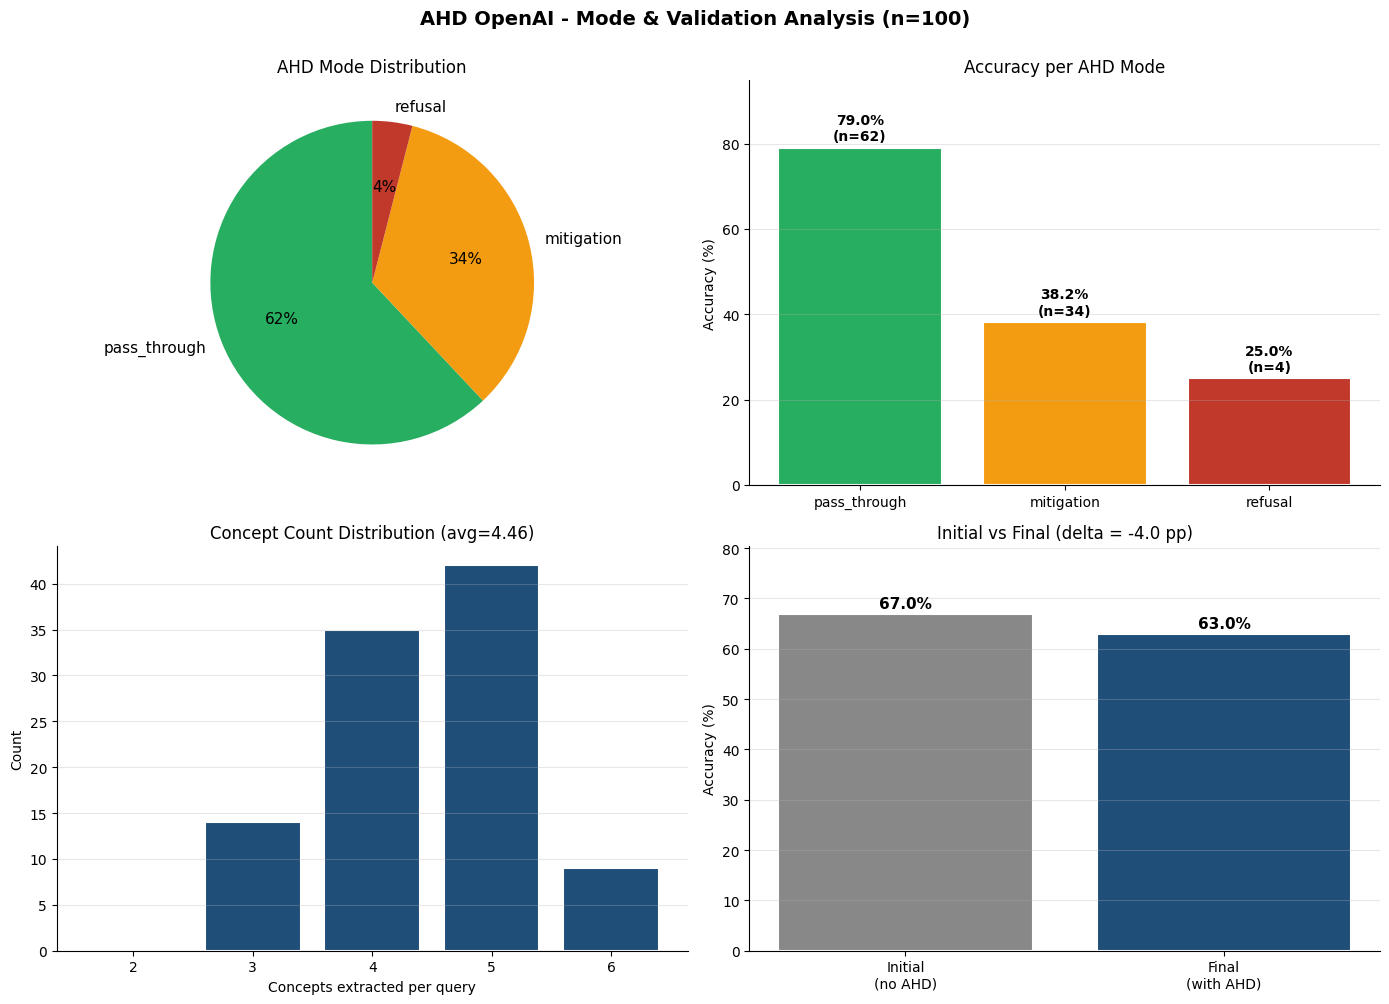


Saved: figures\J_ahd_analysis.png


In [13]:
import matplotlib.pyplot as plt

with open(PHASE1_PATH, 'r', encoding='utf-8') as f:
    p1 = json.load(f)['results']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'AHD OpenAI - Mode & Validation Analysis (n={len(p1)})',
             fontsize=14, fontweight='bold', y=1.00)

# Panel 1: Mode distribution pie
ax = axes[0, 0]
modes = ['pass_through', 'mitigation', 'refusal']
mode_counts = [sum(1 for r in p1 if r['mode'] == m) for m in modes]
colors = ['#27ae60', '#f39c12', '#c0392b']
ax.pie(mode_counts, labels=modes, colors=colors, autopct='%1.0f%%',
       startangle=90, textprops={'fontsize': 11})
ax.set_title('AHD Mode Distribution')

# Panel 2: Per-mode accuracy
ax = axes[0, 1]
mode_acc = []
for m in modes:
    sub = [r for r in p1 if r['mode'] == m]
    a = sum(r['is_correct'] for r in sub) / max(len(sub), 1) * 100
    mode_acc.append(a)
bars = ax.bar(modes, mode_acc, color=colors, edgecolor='white', linewidth=1.5)
for bar, v, c in zip(bars, mode_acc, mode_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.1f}%\n(n={c})', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy per AHD Mode')
ax.set_ylim(0, max(mode_acc) * 1.2 if max(mode_acc) > 0 else 100)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 3: Distribution of concepts extracted per query
ax = axes[1, 0]
n_concepts = [r['n_total'] for r in p1]
ax.hist(n_concepts, bins=range(CONCEPT_MIN, CONCEPT_MAX + 2),
        color='#1f4e79', edgecolor='white', linewidth=1.5, align='left', rwidth=0.8)
ax.set_xlabel('Concepts extracted per query')
ax.set_ylabel('Count')
ax.set_title(f'Concept Count Distribution (avg={np.mean(n_concepts):.2f})')
ax.set_xticks(range(CONCEPT_MIN, CONCEPT_MAX + 1))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 4: Initial vs Final accuracy
ax = axes[1, 1]
init_acc = sum(1 for r in p1 if r['initial_label'] == r['ground_truth']) / len(p1) * 100
final_acc = sum(1 for r in p1 if r['predicted_label'] == r['ground_truth']) / len(p1) * 100
bars = ax.bar(['Initial\n(no AHD)', 'Final\n(with AHD)'],
              [init_acc, final_acc],
              color=['#888888', '#1f4e79'], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, [init_acc, final_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
delta = final_acc - init_acc
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Initial vs Final (delta = {delta:+.1f} pp)')
ax.set_ylim(0, max(init_acc, final_acc) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
FIGURES_DIR = NOTEBOOK_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
out_fig = FIGURES_DIR / 'J_ahd_analysis.png'
plt.savefig(out_fig, dpi=200, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out_fig}')